In [2]:
import xarray as xr
import numpy as np
import os
import matplotlib.pyplot as plt
import netCDF4 as nc
import pandas as pd
import re
from datetime import datetime, timedelta
from importlib import reload
import functions as fct 
reload(fct)

main_path = "/scale/project/ifremer-isi-jumeaunumerique/TC_PRIMED_DATASET/v01r01/final"  #chemin principal des données SARGEO
os.chdir(main_path)

## année - bassin - cyn_number - fichiers_netcdf
annees = [i for i in range(1987, 2025)]    #liste des années
bassins = ['AL', 'CP','EP', 'IO', 'SH', 'WP']  #liste des bassins
os.getcwd()

'/scale/project/ifremer-isi-jumeaunumerique/TC_PRIMED_DATASET/v01r01/final'

créer la base de donnée tcprimed des overpass

In [3]:
# sum = 0
# data = []

# for annee in annees:
#     annee_path = os.path.join(main_path, str(annee))
#     if not os.path.exists(annee_path):
#         continue

#     for bassin in os.listdir(annee_path):
#         bassin_path = os.path.join(annee_path, bassin)

#         for num in os.listdir(bassin_path):
#             num_path = os.path.join(bassin_path, num)
#             files = os.listdir(num_path)

#             for i, path in enumerate(files):
#                 if "_env_" in path:
#                     continue  # on ignore ces fichiers

#                 try:
#                     raw_date = path.split("_")[6].split(".")[0]

#                     date_obj = datetime.strptime(raw_date, "%Y%m%d%H%M%S")
#                     date_iso = date_obj.strftime("%Y-%m-%dT%H:%M:%S.000")

#                     full_path = os.path.join(num_path, path)

#                     data.append([annee, bassin, date_iso, full_path])

#                 except Exception as e:
#                     print(f"⚠️ Erreur avec le fichier {path}: {e}")

# # Création du DataFrame
# df = pd.DataFrame(data, columns=["annee", "bassin", "date", "path"])

# # Sauvegarde en CSV
# csv_path = os.path.join(main_path, "/scale/user/mtannaou/alternance/excels/TCPrimed_overpass.csv")
# df.to_csv(csv_path, index=False, sep=";")

# print(f"✅ Base de données créée : {csv_path}")
# print(f"{len(df)} fichiers enregistrés.")

In [4]:
os.chdir("/scale/user/mtannaou/alternance")
sargeo = pd.read_csv("/scale/user/mtannaou/alternance/excels/SARGEO_modifiee.csv",sep=",")
tcprimed = pd.read_csv("excels/TCPrimed_overpass.csv",sep=";")

In [5]:
sargeo["sar_acquisition_time"] = sargeo["sar_acquisition_time"].str.replace(",", ".")
sargeo.head(1)

,cyclone,canal,fichier,lat_centre,lon_centre,sar_acquisition_time,inter_list_sar,sar_file_path,sar_xy
0,al102019,IRWIN,s1a-iw-owi-cm-20190920t221952-20190920t222132-...,19.548832,298.289185,2019-09-20T22:19:52.000,s1a-iw-owi-cm-20190920t221952-20190920t222132-...,0,NaN


In [6]:
i=0
tcprimed.head(1)


,annee,bassin,date,path
0,1987,EP,1987-07-23T01:05:00.000,/scale/project/ifremer-isi-jumeaunumerique/TC_...


In [7]:
# date1 = sargeo["sar_acquisition_time"].iloc[0]
sum = 0
for date1 in list(sargeo["sar_acquisition_time"]):   #+300 Millions iterations !!!!!!!
    for date in list(tcprimed["date"]) : 
        if fct.is_within_deltamin(date1,date,delta=30):
            sum = sum+1
            break
                
print(len(sargeo))
print(sum)

1406
1043


In [ ]:
import os
import shutil

def copier_fichiers_nc(dossier_source, dossier_cible, liste_noms):
    """
    - dossier_source : dossier où sont les .nc
    - dossier_cible : dossier où copier
    - liste_noms : liste Python contenant les noms recherchés
                   ex: ["file1.nc", "file2.nc"]
    """

    # créer le dossier cible s'il n'existe pas
    os.makedirs(dossier_cible, exist_ok=True)

    copies = 0

    for nom in liste_noms:
        chemin_source = os.path.join(dossier_source, nom)

        if os.path.exists(chemin_source):        # fichier trouvé 
            shutil.copy(chemin_source, dossier_cible)
            print(f"✅ Copié : {nom}")
            copies += 1
        else:
            print(f"⚠️ Introuvable : {nom}")

    print(f"\n✅ {copies} fichiers copiés vers : {dossier_cible}")


In [38]:
liste = [
"rcm1-sclnc-owi-cm-20241004t212518-20241004t212636-00003-xxxxx_aeqd.nc",
"s1a-ew-owi-cm-20241002t083611-20241002t083727-000003-06D630_aeqd.nc",
"rcm1-sclnc-owi-cm-20241007t201754-20241007t201912-00003-xxxxx_aeqd.nc",
"rcm2-sclnd-owi-cm-20241001t081520-20241001t081635-00003-xxxxx_aeqd.nc"]

source = "/scale/user/mtannaou/alternance/donnees_sar_changes"
cible  = "/scale/user/mtannaou/alternance/dossier_mouche_"

copier_fichiers_nc(source, cible, liste)


✅ Copié : rcm1-sclnc-owi-cm-20241004t212518-20241004t212636-00003-xxxxx_aeqd.nc
✅ Copié : s1a-ew-owi-cm-20241002t083611-20241002t083727-000003-06D630_aeqd.nc
✅ Copié : rcm1-sclnc-owi-cm-20241007t201754-20241007t201912-00003-xxxxx_aeqd.nc
✅ Copié : rcm2-sclnd-owi-cm-20241001t081520-20241001t081635-00003-xxxxx_aeqd.nc

✅ 4 fichiers copiés vers : /scale/user/mtannaou/alternance/dossier_mouche_


In [39]:
path = os.listdir("dossier_mouche_")[0]
ds = xr.open_dataset("dossier_mouche_/"+path)
print(ds)

<xarray.Dataset> Size: 42MB
Dimensions:                            (owiAzSize: 507, owiRaSize: 356)
Coordinates:
  * owiAzSize                          (owiAzSize) float64 4kB 9.969e+36 ... ...
  * owiRaSize                          (owiRaSize) float64 3kB 9.969e+36 ... ...
Data variables: (12/33)
    owiLon                             (owiAzSize, owiRaSize) float64 1MB ...
    owiOffboresightAngle               (owiAzSize, owiRaSize) float64 1MB ...
    owiLat                             (owiAzSize, owiRaSize) float64 1MB ...
    owiHeading                         (owiAzSize, owiRaSize) float32 722kB ...
    owiElevationAngle                  (owiAzSize, owiRaSize) float64 1MB ...
    owiIncidenceAngle                  (owiAzSize, owiRaSize) float32 722kB ...
    ...                                 ...
    owiNrcs_cross_no_noise_correction  (owiAzSize, owiRaSize) float64 1MB ...
    owiWindFilter                      (owiAzSize, owiRaSize) float64 1MB ...
    owiWindQuality           

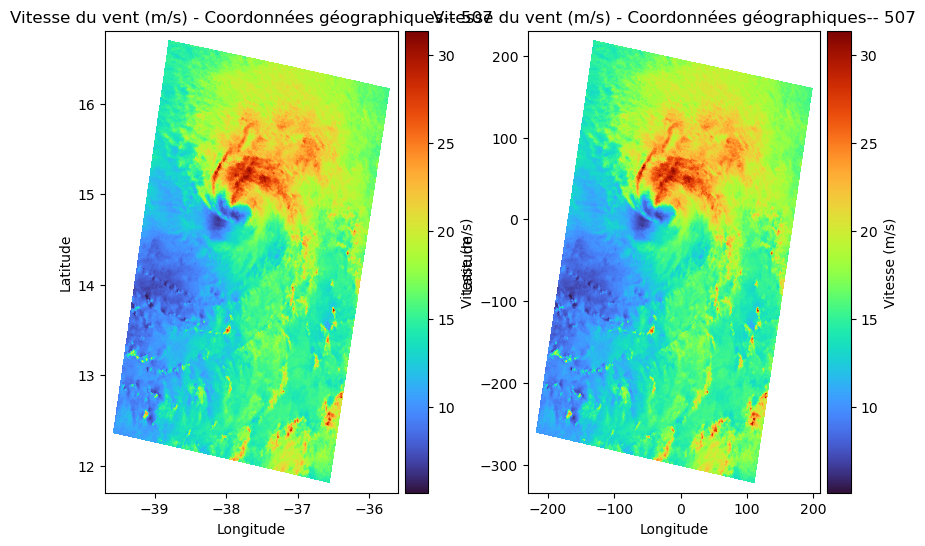

In [ ]:
# --- 2️⃣ Coordonnées géographiques ---
fig,axes = plt.subplots(1,2,figsize=(10,6))
ds_sar_xy = xr.open_dataset("dossier_mouche_/"+path)
im01 = axes[0].pcolormesh(
    ds_sar_xy["owiLon"], ds_sar_xy["owiLat"],
    ds_sar_xy["owiWindSpeed"], cmap="turbo", shading='auto'
)
axes[0].set_title(f"Vitesse du vent (m/s) - Coordonnées géographiques-- {len(ds_sar_xy["owiLon"])}", fontsize=12)
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
cbar01 = fig.colorbar(im01, ax=axes[0], orientation="vertical", pad=0.02)
cbar01.set_label("Vitesse (m/s)", rotation=90)

im012= axes[1].pcolormesh(
    ds_sar_xy["x_sar"], ds_sar_xy["y_sar"],
    ds_sar_xy["owiWindSpeed"], cmap="turbo", shading='auto'
)
axes[1].set_title(f"Vitesse du vent (m/s) - Coordonnées géographiques-- {len(ds_sar_xy["owiLon"])}", fontsize=12)
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")
cbar01 = fig.colorbar(im01, ax=axes[1], orientation="vertical", pad=0.02)
cbar01.set_label("Vitesse (m/s)", rotation=90)

im012= axes[1].pcolormesh(
    ds_sar_xy["x_sar"], ds_sar_xy["y_sar"],
    ds_sar_xy["owiWindSpeed"], cmap="turbo", shading='auto'
)
axes[1].set_title(f"Vitesse du vent (m/s) - Coordonnées géographiques-- {len(ds_sar_xy["owiLon"])}", fontsize=12)
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")
cbar01 = fig.colorbar(im01, ax=axes[1], orientation="vertical", pad=0.02)
cbar01.set_label("Vitesse (m/s)", rotation=90)